<h1 style="color: #87dee4; font-size: 40px; font-family: monospace;">
    Introdução
</h1>

<text style="color: #e8ebce; font-family: monospace;">
    Esta é uma análise realizada a partir de formulários aplicados nas turmas do 6º, 8º e 9º do ensino fundamental em uma escola municipal, durante a minha bolsa no PIBID. <br>
    <strong>Importante:</strong> Os formulários foram respondidos de forma totalmente anônima!
</text>

<h2 style="color: #87dee4; font-family: monospace;">
    Objetivo
</h2>

<text style="color: #e8ebce; font-family: monospace;">
     O intuito desta análise é investigar a relação dos alunos com a disciplina de ciências na escola.
</text>

---

Primeiro, irei importar as bibliotecas que serão utilizadas para esta análise!


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Agora vou importar as planilhas que foram geradas dos formulários.


In [82]:
sexto_ano = pd.read_excel("../Planilhas/Questionário 6º ano (respostas).xlsx")
oitavo_ano = pd.read_excel("../Planilhas/Questionário 8º ano (respostas).xlsx")
nono_ano = pd.read_excel("../Planilhas/Questionário 9º ano (respostas).xlsx")

---

<h3 style="color: #87dee4; font-family: monospace;">
    Limpeza dos Dados
</h3>

Limpei os nomes das colunas, removendo espaços em branco e convertendo para letras minúsculas, para facilitar a manipulação dos dados posteriormente.


In [83]:
sexto_ano.columns = sexto_ano.columns.str.strip()
oitavo_ano.columns = oitavo_ano.columns.str.strip()
nono_ano.columns = nono_ano.columns.str.strip()

Aqui eu estou criando uma coluna 'Turma' para facilitar a filtragem dos dados quando eu juntar todos os dados em uma tabela só.


In [84]:
sexto_ano['Turma'] = '6º ano'
oitavo_ano['Turma'] = '8º ano'
nono_ano['Turma'] = '9º ano'

In [85]:
dados = pd.concat([sexto_ano, oitavo_ano, nono_ano], ignore_index=True)

Agora, vou checar para ver como ficou as colunas do Dataframe.


In [86]:
print(dados.columns)

Index(['Melhores metodologias', 'Escala de 1 a 5, quanto gosta de ciências?',
       'Somente a aula é suficiente para aprender?', 'Meio de estudo',
       'Quais outros ambientes você acha que podem agregar na compreensão sobre um conteúdo?',
       'Você participa de alguma atividades fora da escola (como esporte, escutar música, participar de clubes, dançar, teatro, etc.)?',
       'Quais dispositivos com acesso a internet você costuma utilizar na sua casa?',
       'Onde você costuma acessar a internet para estudar?',
       'Quais dificuldades você encontra para conseguir aprender a disciplina de ciências?',
       'Como você avalia a estrutura da escola?',
       'Maior dificuldade no estudo',
       'Você se sente confortável em expor a sua opinião ou tirar dúvidas nos momentos em sala de aula?',
       'O que faz você não querer participar das aulas?',
       'Escreva com o máximo de detalhes possíveis uma possível solução para o problema relatado na seção anterior:',
       'T

Cada planilha tinha a mesma pergunta, mas com o enunciado ligeiramente diferente, então vou combinar as colunas correspondentes em uma única coluna 

In [87]:
dados["atividade_fora_escola"] = (
    dados["Você participa de alguma atividades fora da escola (como esporte, escutar música, participar de clubes, dançar, teatro, etc.)?"]
    .combine_first(
        dados["Você participa de alguma atividade fora da escola (como esporte, escutar música, participar de clubes, dançar, teatro, etc.)?"]
    )
)

In [89]:
dados["solucao_problema"] = (
    dados["Escreva com o máximo de detalhes possíveis uma possível solução para o problema relatado na seção anterior:"]
    .combine_first(
        dados["Escreva com o máximo de detalhes possíveis uma ou mais soluções para o problema relatado na seção anterior:"]
    )
)

Removendo as colunas originais que foram combinadas


In [ ]:
dados = dados.drop(columns=[
"você participa de alguma atividades fora da escola (como esporte, escutar música, participar de clubes, dançar, teatro, etc.)?",
"você participa de alguma atividade fora da escola (como esporte, escutar música, participar de clubes, dançar, teatro, etc.)?",
"escreva com o máximo de detalhes possíveis uma possível solução para o problema relatado na seção anterior:",
"escreva com o máximo de detalhes possíveis uma ou mais soluções para o problema relatado na seção anterior:"
])

Irei renomear as colunas para ficarem mais curtas e objetivas


In [ ]:
dados = dados.rename(columns={
"melhores metodologias": "metodologias",
"escala de 1 a 5, quanto gosta de ciências?": "gosta_ciencias",
"somente a aula é suficiente para aprender?": "aula_suficiente",
"meio de estudo": "meios_estudo",
"maior dificuldade no estudo": "dificuldade_estudo",
"quais dispositivos com acesso a internet você costuma utilizar na sua casa?" : "dispositivos_internet",
"onde você costuma acessar a internet para estudar?" : "local_acesso_internet",
"quais dificuldades você encontra para conseguir aprender a disciplina de ciências?" : "dificuldades_ciencias",
"você se sente confortável em expor a sua opinião ou tirar dúvidas nos momentos em sala de aula?" : "conforto_expor_opniao",
"o que faz você não querer participar das aulas?" : "motivo_nao_participar_aulas",

})

In [ ]:
print(dados.columns)

Index(['metodologias', 'gosta_ciencias', 'aula_suficiente', 'meios_estudo',
       'quais outros ambientes você acha que podem agregar na compreensão sobre um conteúdo?',
       'dispositivos_internet', 'local_acesso_internet',
       'dificuldades_ciencias', 'como você avalia a estrutura da escola?',
       'dificuldade_estudo', 'conforto_expor_opniao',
       'motivo_nao_participar_aulas', 'Turma', 'atividade_fora_escola',
       'solucao_problema'],
      dtype='str')


Os formulários foram feitos para entender a realidade do aluno, o que eles fazem no tempo livre, se eles tem acesso a internet. Era importante saber essas informações, pois queriamos passar atividades que fossem condizentes com a realidade da maioria, e que eles fossem gostar também.
Mas como aqui estamos somente avaliando a relação deles com a disciplina de ciências, eu vou remover algumas colunas que eu não irei utilizar para a análise.


In [90]:
colunas_para_remover = ['quais outros ambientes você acha que podem agregar na compreensão sobre um conteúdo?','atividade_fora_escola', 'solucao_problema'
                        , 'como você avalia a estrutura da escola?']

In [ ]:
dados_atualizados = dados.drop(columns=colunas_para_remover)

Agora vou tratar os valores nulos, substituindo-os por "Não informado" para facilitar a análise dos dados posteriormente


In [ ]:
print(dados_atualizados.isnull().sum())

metodologias                    0
gosta_ciencias                  0
aula_suficiente                 0
meios_estudo                   77
dispositivos_internet           0
local_acesso_internet           0
dificuldades_ciencias           9
dificuldade_estudo              1
conforto_expor_opniao           0
motivo_nao_participar_aulas    46
Turma                           0
dtype: int64


É importante tratar esses dados para ficar melhor a visualização dos gráficos posteriormente. E também deixa mais limpo a tabela, invés de espaços vazios.


In [ ]:
dados_atualizados = dados_atualizados.fillna("Não informado")

In [ ]:
print(dados_atualizados.isnull().sum())

metodologias                   0
gosta_ciencias                 0
aula_suficiente                0
meios_estudo                   0
dispositivos_internet          0
local_acesso_internet          0
dificuldades_ciencias          0
dificuldade_estudo             0
conforto_expor_opniao          0
motivo_nao_participar_aulas    0
Turma                          0
dtype: int64


---

<h3 style="color: #87dee4; font-family: monospace;">
    Análise
</h3>

Pontos interessantes para analisar:
1. Qual é a média de gosto por ciências entre as turmas?
2. Qual é a porcentagem de alunos que acham que somente a aula é suficiente para aprender ciências?
3. Quais são as maiores dificuldades que os alunos encontram para aprender ciências?
4. Qual é a porcentagem de alunos que se sentem confortáveis em expor suas opiniões ou tirar dúvidas em sala de aula?

É importante ressaltar, que apenas aplicamos os formulários nas turmas onde a nossa professora supervisora atuava. Então o quantitativo de alunos entre as turmas que responderam o formulário no dia aplicado variou bastante.

- 6º: 24 alunos
- 8º: 26 alunos
- 9º: 67 alunos (total de alunos de três turmas)

### 1. Calculando a média (escala de 1 a 5) do gosto por ciências entre as turmas.

In [ ]:
media_gosto_ciencias = dados_atualizados.groupby("Turma")["gosta_ciencias"].mean()
print(round(media_gosto_ciencias, 1))

Turma
6º ano    3.0
8º ano    3.1
9º ano    3.2
Name: gosta_ciencias, dtype: float64


Como podemos analisar, há apenas uma leve diferença entre as turmas esta média. Podemos dizer que todos não desgotam e também não amam muito a disciplina.

Agora no gráfico:

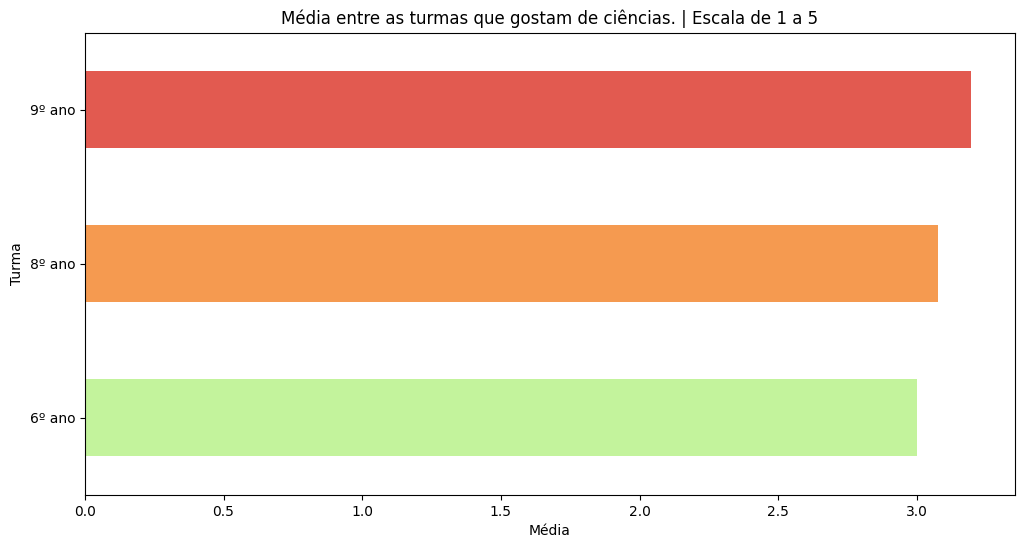

In [ ]:
plt.figure()
media_gosto_ciencias.plot(kind="barh",figsize=[12,6], color=["#C3F39C", "#F59A50", "#E25A50"])
plt.title('Média entre as turmas que gostam de ciências. | Escala de 1 a 5')
plt.xlabel('Média')
plt.ylabel('Turma')
plt.show()

### 2. Calculando a porcentagem de alunos que acreditam que somente a aula de ciências é o suficiente para aprender a disciplina.

In [ ]:
percentual_aula_suficiente = (
    dados_atualizados.groupby('Turma')['aula_suficiente'].value_counts(normalize=True) * 100
)
print(round(percentual_aula_suficiente,1))

Turma   aula_suficiente
6º ano  Sim                70.8
        Não                29.2
8º ano  Sim                73.1
        Não                26.9
9º ano  Sim                76.1
        Não                23.9
Name: proportion, dtype: float64


Antes de analisar por completo, visualmente quando formos fazer um gráfico, será necessário separar cada percentual com a sua respectiva turma.

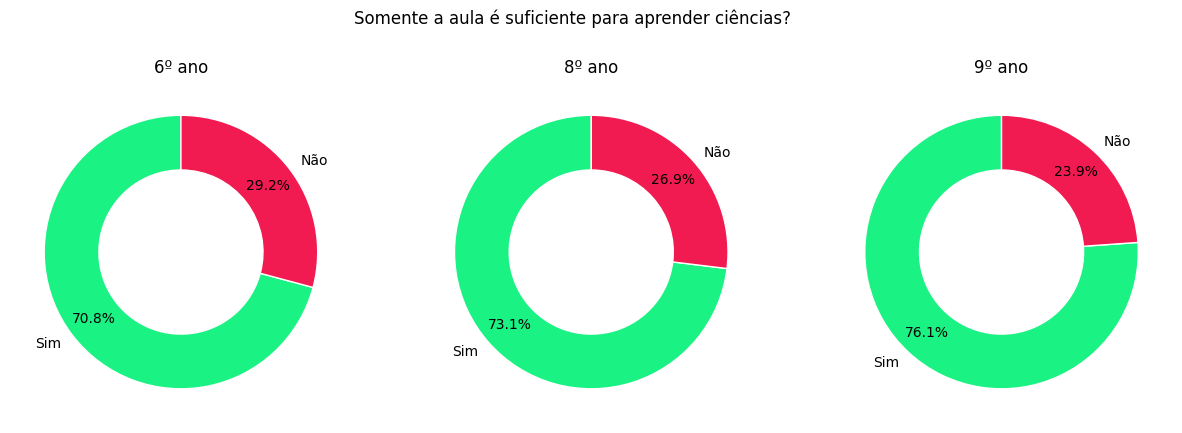

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

turmas_aula = percentual_aula_suficiente.index.levels[0]

turmas = ['6º ano', '8º ano', '9º ano']
for i, turma in enumerate(turmas):
    dados_p_AS =  percentual_aula_suficiente.loc[turma]
    
    axes[i].pie(
        dados_p_AS.values,
        labels=dados_p_AS.index,
        autopct='%1.1f%%',
        colors=['#1BF284', '#F21B51'],
        startangle=90,
        wedgeprops={'width': 0.4, 'edgecolor': 'white'},
        pctdistance=0.8
    )
    axes[i].set_title(turma)


plt.suptitle('Somente a aula é suficiente para aprender ciências?')


Conseguimos perceber que as três turmas, em sua grande maioria, acredita que assistindo a aula já é o suficiente para aprender.

Entretanto, ainda há uma porcentagem, maior na turma do 6º ano, de alunos que acreditam que não é suficiente. Então, vamos analisar as dificuldades gerais primeiro de todos os alunos, e depois, deles em específico!

### 3. Maiores dificuldades que os alunos encontram para aprender ciências em sala de aula.

In [ ]:
print(dados_atualizados['dificuldades_ciencias'].value_counts())

dificuldades_ciencias
[Conversa paralela]                                                                                                        47
[Concentração para copiar conteúdo do quadro]                                                                              26
[Falta de materiais didáticos diversos]                                                                                    13
[Organizar o conteúdo no caderno]                                                                                          12
[Não informado]                                                                                                             9
[Não gosto da disciplina]                                                                                                   1
[Concentração para copiar conteúdo do quadro,  Conversa paralela,  Organizar o conteúdo no caderno]                         1
[Concentração para copiar conteúdo do quadro,  Conversa paralela,  Falta de materiais didáticos 

Primeiro, eu vou realizar um tratamento para esses dados, pois muitos deles tem mais de uma resposta na mesma linha e eu quero contabilizar todas!

In [ ]:
dados_atualizados['dificuldades_ciencias'] = (
    dados_atualizados['dificuldades_ciencias']
    .str.split(',') #Separando as respostas que estão entre ","!
)

Utilizei o explode para tratar as múltiplas respostas em uma única célula

In [ ]:
dificuldade_atualizado = dados_atualizados.explode('dificuldades_ciencias')

In [ ]:
dificuldade_atualizado['dificuldades_ciencias'] = (
    dificuldade_atualizado['dificuldades_ciencias']
    .str.strip()
    .str.capitalize()
    
)


In [ ]:
print(dificuldade_atualizado['dificuldades_ciencias'].value_counts())

dificuldades_ciencias
Conversa paralela                              54
Concentração para copiar conteúdo do quadro    32
Organizar o conteúdo no caderno                18
Falta de materiais didáticos diversos          15
Não informado                                   9
Não gosto da disciplina                         3
Cansaço                                         1
Name: count, dtype: int64


Agora para o cálculo:

In [ ]:
percentual_dificuldades = dificuldade_atualizado.groupby('Turma')['dificuldades_ciencias'].value_counts(normalize=True) *100

percentual_dificuldades = round(percentual_dificuldades,1)

print(percentual_dificuldades)

Turma   dificuldades_ciencias                      
6º ano  Conversa paralela                              58.3
        Concentração para copiar conteúdo do quadro    20.8
        Organizar o conteúdo no caderno                12.5
        Falta de materiais didáticos diversos           8.3
8º ano  Conversa paralela                              42.3
        Concentração para copiar conteúdo do quadro    34.6
        Falta de materiais didáticos diversos          11.5
        Organizar o conteúdo no caderno                 7.7
        Não gosto da disciplina                         3.8
9º ano  Conversa paralela                              35.4
        Concentração para copiar conteúdo do quadro    22.0
        Organizar o conteúdo no caderno                15.9
        Falta de materiais didáticos diversos          12.2
        Não informado                                  11.0
        Não gosto da disciplina                         2.4
        Cansaço                                 

Fazendo o gráfico para análise:

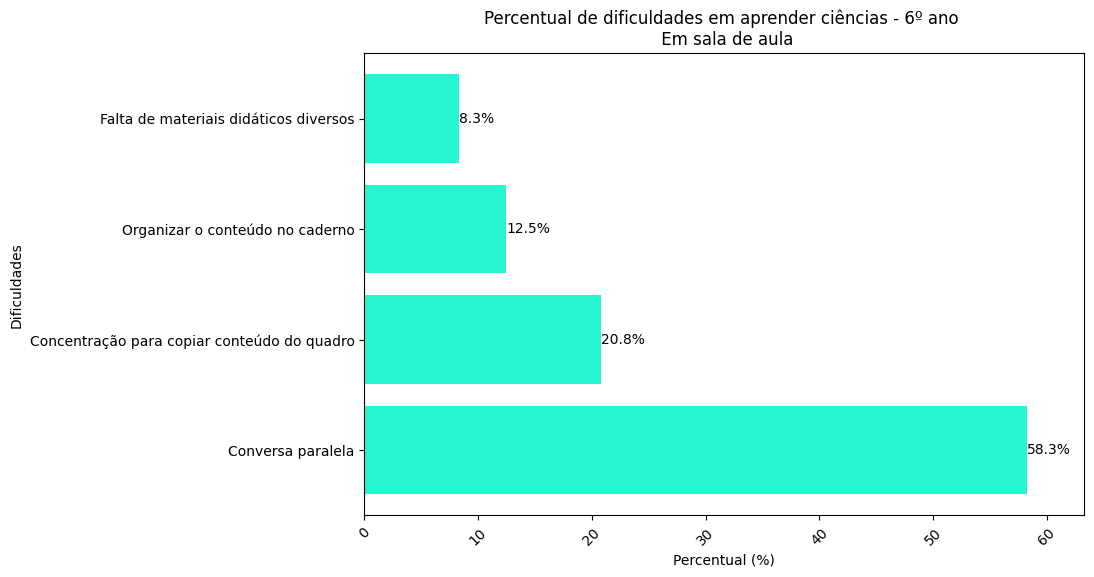

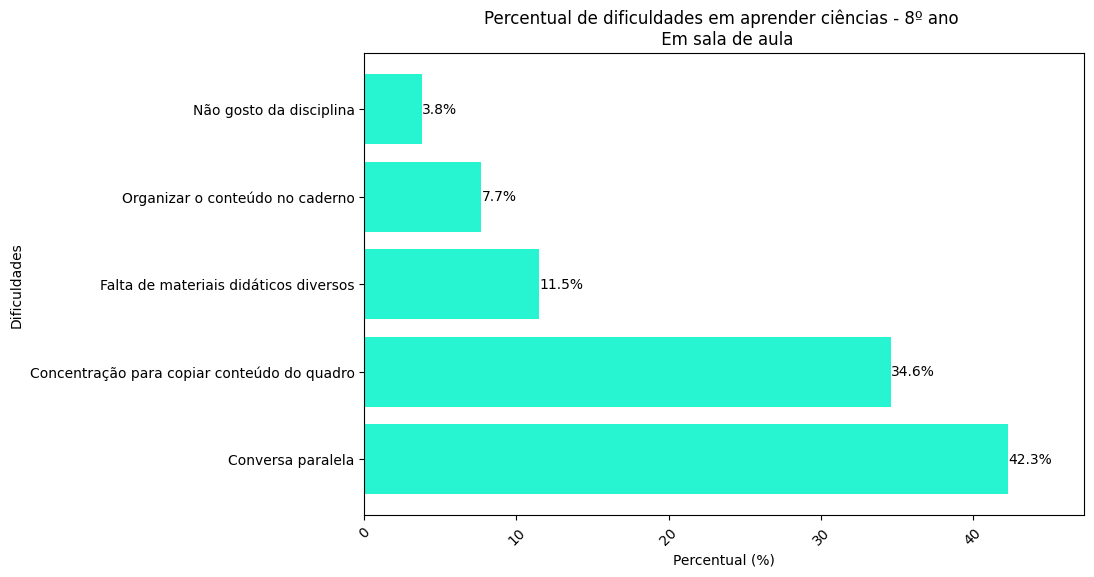

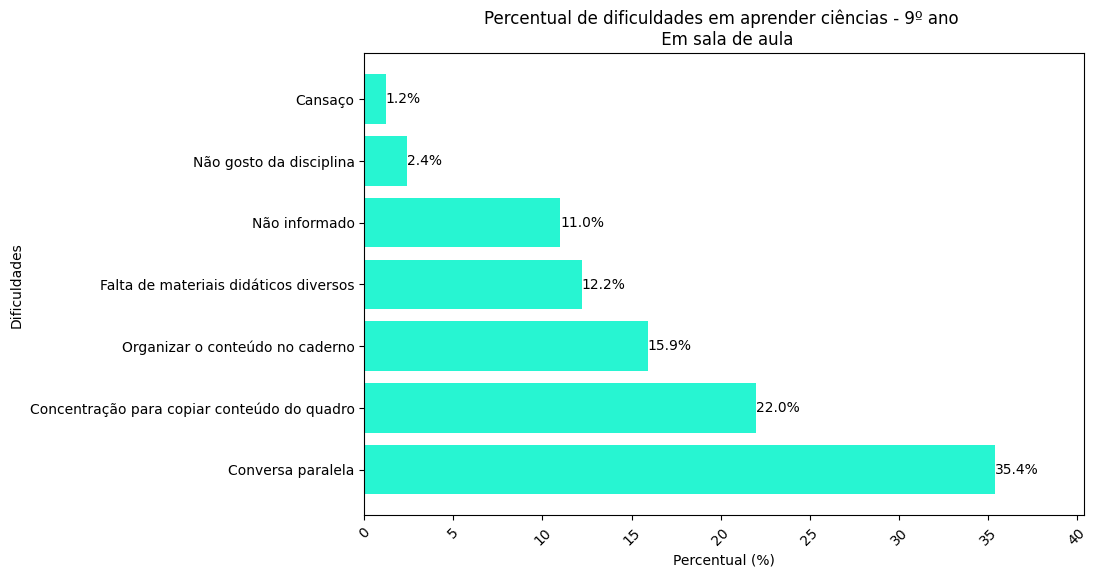

In [ ]:
for i, turma in enumerate(turmas):
    dados_pd = percentual_dificuldades.loc[turma]
    
    fig, ax = plt.subplots(figsize=(12,6))
    
    plt.barh(
        dados_pd.index,
        dados_pd.values,
        color="#27F5D2",
        
        
    )
    bars = plt.barh(dados_pd.index, dados_pd.values, color = "#27F5D2")
    
    #Estou ajustando para colocar os percentuais correspondentes de cada barra
    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%',
            va='center'
        )
    
    plt.title(f"Percentual de dificuldades em aprender ciências - {turma} \n Em sala de aula")
    plt.xlabel("Percentual (%)")
    plt.xticks(rotation=45)
    plt.subplots_adjust(left=0.3) #Ajustei a margem da esquerda para aparecer os valores
    plt.ylabel("Dificuldades")
    plt.xlim(0,max(dados_pd.values)+ 5 ) #Ajustei a margem das barras para visualizar melhor as porcentagens ao lado

Percebe-se com o gráfico que a maior dificuldade dos alunos, de TODAS as turmas, para aprender ciências, é a conversa paralela entre os alunos. O que muito provavelmente, tira o foco e a concentração. O que é interessante, é que a conversa paralela é provocado por eles mesmos, então eles mesmos se sabotam.
Também é interessante analisar que a turma do 6º ano, foi a única turma que ninguém externou que o fato de não gostar da disciplina e/ou não achá-la importante, fosse um fator que dificultasse o aprendizado.
Além disso:
- A turma do 6º teve um maior percentual de alunos (do que as outras turmas) que acham que a conversa paralela atrapalha;
- O 8º ano tem o maior percentual de alunos que sentem dificuldade em se concentrar para copiar o conteúdo do quadro;
- O 9º ano foi a única turma que os alunos deixaram espaço em branco ("não informado") na resposta

### 3.2 Analisando as dificuldades de aprender ciências em sala de aula por aqueles marcaram que a aula de ciências não é suficiente para o aprendizado.

Filtrando apenas aqueles que responderam "Não"

Estou fazendo uma cópia para não mexer com o original

In [ ]:
df_dificuldades = dificuldade_atualizado.copy()

In [ ]:
filtro = df_dificuldades['aula_suficiente'] == 'Não'

dificuldade_alunos = df_dificuldades.loc[
    filtro, ['Turma', 'dificuldades_ciencias']
]

dificuldade_alunos['dificuldades_ciencias'] = (
    dificuldade_alunos['dificuldades_ciencias']
    .str.capitalize()
)

print(dificuldade_alunos.value_counts())

Turma   dificuldades_ciencias                      
9º ano  Conversa paralela                              6
        Concentração para copiar conteúdo do quadro    6
6º ano  Conversa paralela                              4
9º ano  Organizar o conteúdo no caderno                4
8º ano  Conversa paralela                              3
        Concentração para copiar conteúdo do quadro    3
6º ano  Falta de materiais didáticos diversos          2
9º ano  Falta de materiais didáticos diversos          2
6º ano  Concentração para copiar conteúdo do quadro    1
8º ano  Falta de materiais didáticos diversos          1
9º ano  Cansaço                                        1
        Não gosto da disciplina                        1
Name: count, dtype: int64


Agora realizar o cálculo:

In [ ]:
percentual_alunos_dificuldade = dificuldade_alunos.groupby('Turma')['dificuldades_ciencias'].value_counts(normalize='True') * 100

percentual_alunos_dificuldade = round(percentual_alunos_dificuldade,1)

print(percentual_alunos_dificuldade)

Turma   dificuldades_ciencias                      
6º ano  Conversa paralela                              57.1
        Falta de materiais didáticos diversos          28.6
        Concentração para copiar conteúdo do quadro    14.3
8º ano  Conversa paralela                              42.9
        Concentração para copiar conteúdo do quadro    42.9
        Falta de materiais didáticos diversos          14.3
9º ano  Conversa paralela                              30.0
        Concentração para copiar conteúdo do quadro    30.0
        Organizar o conteúdo no caderno                20.0
        Falta de materiais didáticos diversos          10.0
        Cansaço                                         5.0
        Não gosto da disciplina                         5.0
Name: proportion, dtype: float64


Colocando em gráfico:

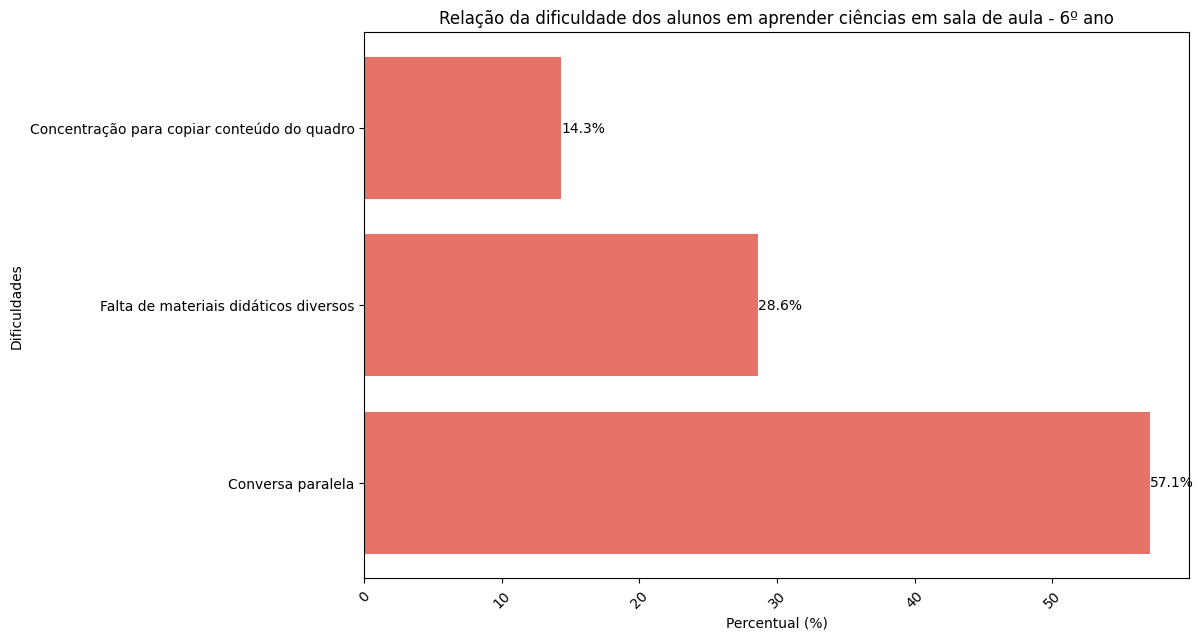

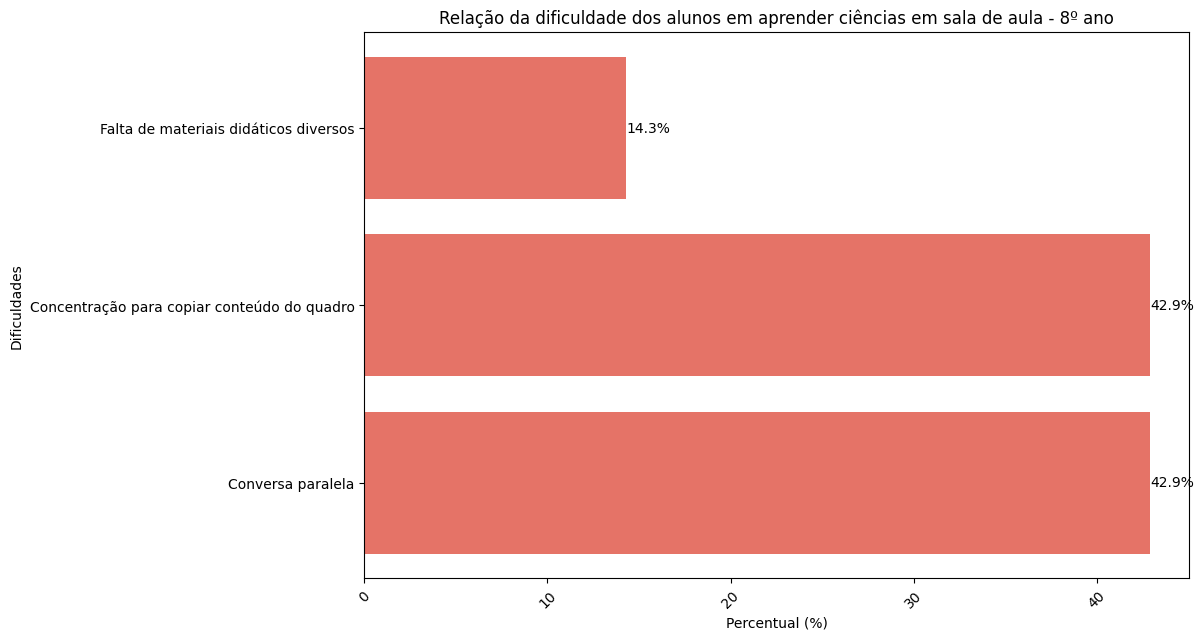

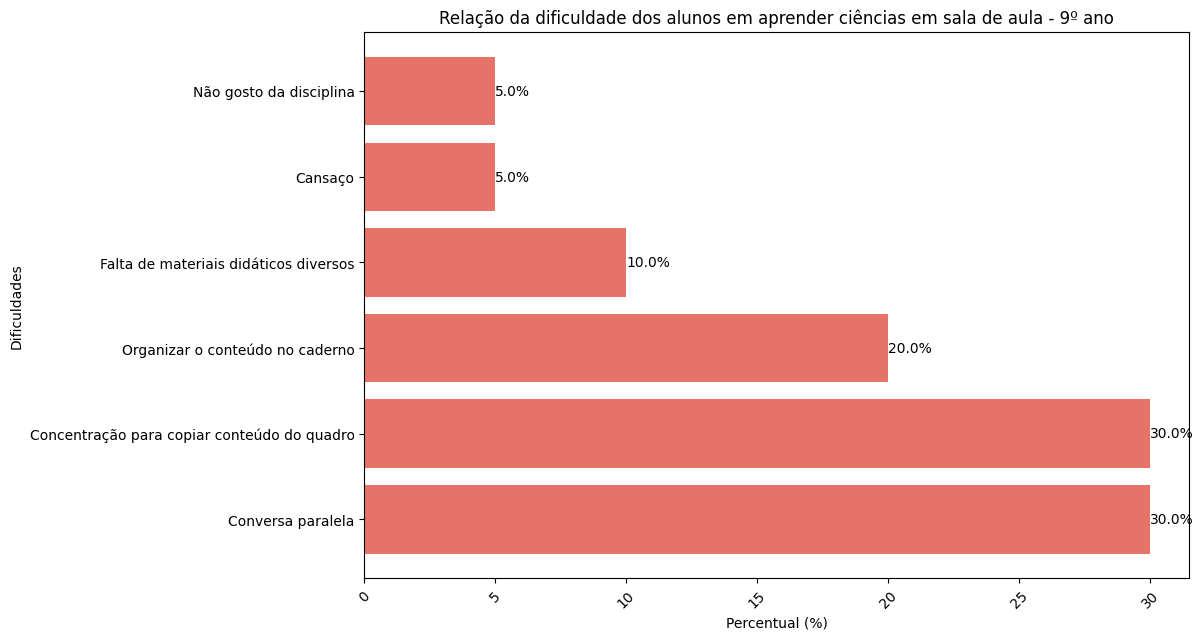

In [ ]:
for i, turma in enumerate(turmas):
    dados_pad = percentual_alunos_dificuldade.loc[turma]
    
    fig, ax = plt.subplots(figsize=(12,6))
    
    plt.barh(
        dados_pad.index,
        dados_pad.values,
        color="#E57367",
        
        
    )
    bars = plt.barh(dados_pad.index, dados_pad.values, color = "#E57367")
    
    
    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%',
            va='center',
            
        )
    plt.tight_layout()
    plt.title(f"Relação da dificuldade dos alunos em aprender ciências em sala de aula - {turma}")
    plt.xlabel("Percentual (%)")
    plt.xticks(rotation=45)
    plt.subplots_adjust(left=0.3) 
    plt.ylabel("Dificuldades") 


Agora, filtrando apenas os alunos que disseram que somente a aula era insuficiente para aprender, conseguimos analisar quais são as dificuldades enfrentadas especificamente por eles!

Na turma do 6º ano:

- A organização do conteúdo do caderno não é um problema;
- A falta de materias didáticos diversos tem uma porcentagem maior, então pode-se interpretar que eles precisam de métodos de ensino mais variados para conseguir aprender, pois o tradicional não está sendo suficiente.
- Conversa paralela ainda é um agravante.


Na turma do 8º ano:

- Nenhum aluno que diz que a aula não é suficiente para aprender, afirmou não gostar da disciplina, ao contrário do gráfico geral!
- Assim como na turma do 6º ano, a organização do conteúdo no caderno não é um problema;
- Os alunos sentem mais dificuldade em conseguir se concentrar para copiar o conteúdo no quadro, que deve estar atrelado com a conversa paralela que está com o mesmo nível de porcentagem 

Na turma do 9º ano:

- Muito provavelmente as categorias "cansaço" e "não gosto da disciplina" desta turma partiram dessa filtragem de alunos. Logo, para eles, não gostar da disciplina está surtindo um efeito negativo para a aprendizagem. 
- Ao contrário das outras turmas, a organização do conteúdo no caderno é impactante para o aprendizado.
- Assim como na turma do 8º, a concentração para copiar o conteúdo no quadro divide a mesma porcentagem que a conversa paralela.


No geral, conseguimos perceber que a conversa entre todas as turmas é um fator agravante que dificulta o ensino tanto para aqueles que conseguem aprender com a aula, quanto para aqueles que não conseguem. Que por consequência, afeta a concentração, dificulta os alunos a realizarem atividades e a copiarem o conteúdo.

Diante deste problema, se torna extremamente necessário adotar medidas que diminuam a conversa entre os alunos. A aplicação de atividades mais complexas que exigam uma concentração maior dos alunos para conseguir entender o que está sendo passado, acaba sendo o essencial. Assim, a conversa paralela se torna uma conversa de troca de idéias e conhecimento.

### 4. Qual é a porcentagem dos alunos, por turma, que se sentem confortáveis em tirar dúvidas e expor suas opniões?

Conseguimos entender, através desta análise, que há uma porcentagem significativa de alunos que acreditam que a falta de materiais didáticos diversos é um fator que dificulta o aprendizado, deixando muito provavelmente a aula monótoma. 

Por ser uma categoria onde a solução poderia vim da professora, é interessante analisar se eles se sentem confortáveis de expor essa questão. Claro que nem toda aula é possível fazer experimentos e jogos dinâmicos.

Eu vou primeiro modificar um pouco as respostas, pois elas estão muito longas, o que funciona para o google forms, mas para a visualização no gráfico, não muito.

In [ ]:
dados_atualizados['opniao_duvida'] = dados_atualizados['conforto_expor_opniao'].replace({
    
    'Sim, sempre tiro todas as minhas dúvidas e exponho a minha opinião' : 'Sempre',
    'Não, pois não me sinto confortável em tirar dúvidas ou expor a minha opinião': 'Nunca',
    'Raramente tiro dúvidas e exponho a minha opinião' : 'Raramente'
})

In [ ]:
print(dados_atualizados['opniao_duvida'])

0         Sempre
1         Sempre
2          Nunca
3      Raramente
4          Nunca
         ...    
112    Raramente
113    Raramente
114    Raramente
115    Raramente
116    Raramente
Name: opniao_duvida, Length: 117, dtype: str


Agora que está mais curto, vamos para o cálculo:

In [ ]:
percentual_opniao = dados_atualizados.groupby('Turma')['opniao_duvida'].value_counts(normalize=True).unstack() *100

percentual_opniao = round(percentual_opniao,1)
print(percentual_opniao)

opniao_duvida  Nunca  Raramente  Sempre
Turma                                  
6º ano          29.2       41.7    29.2
8º ano          11.5       46.2    42.3
9º ano          16.4       55.2    28.4


Colocando em um gráfico:

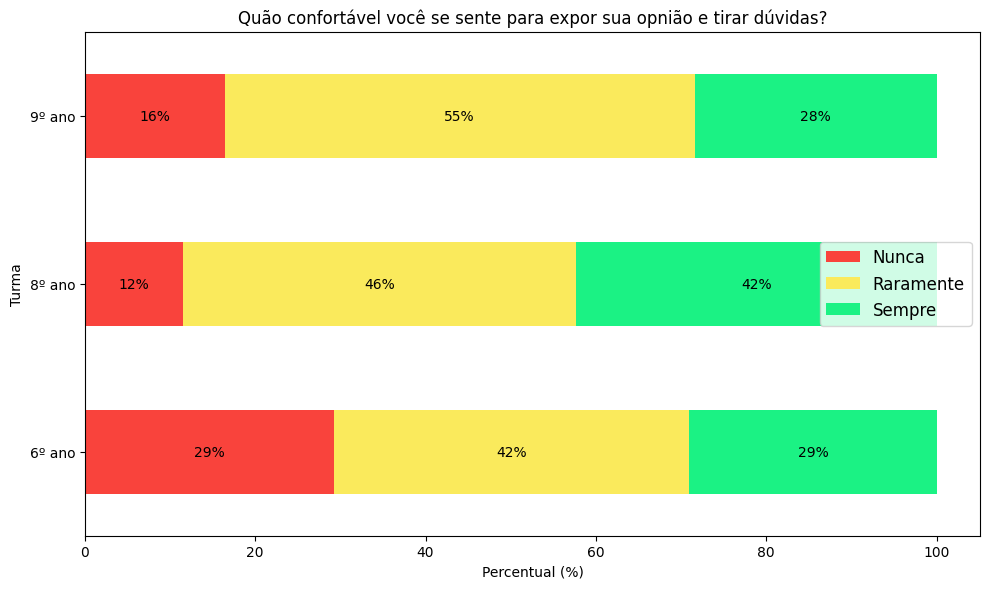

In [ ]:
cores = ['#F9433C','#FAEA5C','#1BF284']

fig,ax = plt.subplots( figsize=(10,6))
percentual_opniao.plot(kind='barh', stacked= True, color=cores, ax = ax)

for i, turma in enumerate(percentual_opniao.index):
    
    acumulado = 0 #Para controlar onde começa cada pedaço da barra
    
    for valor in percentual_opniao.loc[turma]:
        if valor > 5: #Maior que 5%
            ax.text(
                acumulado + valor/2,
                i,
                f'{valor:.0f}%',
                va='center',
                ha='center'
            )
        acumulado += valor
    plt.title('Quão confortável você se sente para expor sua opnião e tirar dúvidas?')
    plt.xlabel("Percentual (%)")
    plt.tight_layout()
handles,_=ax.get_legend_handles_labels()
ax.legend(handles, ['Nunca', 'Raramente', 'Sempre'], fontsize=12)

Aqui conseguimos analisar que de maneira geral, todas as turmas raramente expõem suas opniões e/ou tiram suas dúvidas com os colegas ou com a professora.

- Na turma do 8º, os alunos, de longe, são os mais confortáveis!
- No 6º ano, há a mesma quantidade de alunos que não se sentem confortáveis quanto aqueles que sentem.
- No 9º ano, há um percentual maior que das outras turmas de alunos que raramente se sentem confortáveis.

O que conseguimos perceber é que os alunos, de modo geral, tiram dúvidas e expõem suas opniões, mesmo que não seja de maneira contínua. Desse modo, podemos concluir que o ambiente das turmas não é tão pesado, principalmente referente em tirar dúvidas, o que é um bom ponto para a professora!

Referente ao alunos que nunca se sentem a vontade, é interessante investigar a causa. Pois pode ser apenas vergonha ou como pode ser também ser fatores mais agravantes, como medo dos colegas, bullying entre outros.

Como a turma do 6º há uma porcentagem maior do que as outras turmas, é interessante investigar como é a dinâmica dessa turma, principalmente as relações entre os alunos.